In [8]:
z = [1,2,3,4,5]
z[1]

2

In [9]:
z[0]

1

In [3]:
import numpy as np

In [4]:
x = np.array([1,5,8,6])
x

array([1, 5, 8, 6])

In [12]:
y = np.linspace(0,20, 10)

In [13]:
y

array([ 0.        ,  2.22222222,  4.44444444,  6.66666667,  8.88888889,
       11.11111111, 13.33333333, 15.55555556, 17.77777778, 20.        ])

In [16]:
v = np.arange(2,20,2)
v

array([ 2,  4,  6,  8, 10, 12, 14, 16, 18])

In [17]:
v**2

array([  4,  16,  36,  64, 100, 144, 196, 256, 324])

In [18]:
v/2

array([1., 2., 3., 4., 5., 6., 7., 8., 9.])

In [6]:
n = np.array([0,1,2,3,4,5])
x = n*(n+1) / 2
x

array([ 0.,  1.,  3.,  6., 10., 15.])

C:\Users\great\AppData\Local\Temp\ipykernel_3732\4055792422.py:19: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  return np.sum(a(n, N) for n in range(1,m+1))


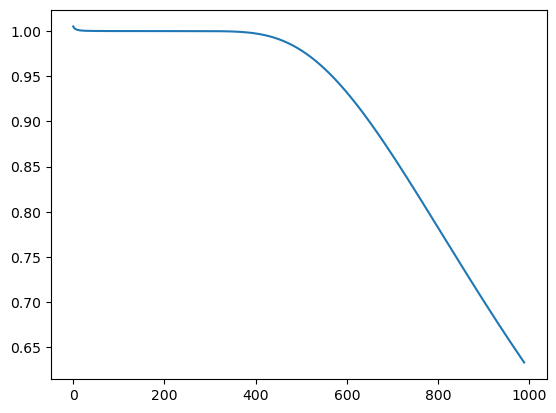

In [7]:

import numpy as np

import math

import matplotlib.pyplot as plt

 

def a(n, N):

  return (-1)**math.floor((n-1)/2)*np.exp(-n**2/N**2)

#   return (-1)**math.floor((n-1)/2)*np.exp(-n**4/N**4)

 

def s(m,N):

    return np.sum(a(n, N) for n in range(1,m+1))

 

plt.plot([s(1000,N) for N in range(10, 1000)])

plt.show()


In [9]:
#Eta regularisation and sum of naturals test

import numpy as np

def eta(x):
    return np.exp(-x) * (1 - x/2)

def smoothed_sum(N, cutoff_factor=50):
    # Goal: approximate sum_{n=1}^∞ n * eta(n/N).
    # Since eta decays exponentially, summing to cutoff_factor * N
    # is enough for a simple numerical approximation.

    n = np.arange(1, int(cutoff_factor * N) + 1, dtype=float)
    return np.sum(n * eta(n / N))

for N in [10, 20, 50, 100, 200, 500, 1000, 2000]:
    value = smoothed_sum(N)
    print(f"N = {N:4d}, smoothed sum = {value:.12f}")

N =   10, smoothed sum = -0.083250049580
N =   20, smoothed sum = -0.083312503100
N =   50, smoothed sum = -0.083330000079
N =  100, smoothed sum = -0.083332500005
N =  200, smoothed sum = -0.083333125001
N =  500, smoothed sum = -0.083333300003
N = 1000, smoothed sum = -0.083333324995
N = 2000, smoothed sum = -0.083333331150


In [11]:
#Using smoothed asymptotics, we see that the sum of naturals "equals" -1/12
#Hypothesis: the full smoothed sum produces positive and negative contributions whose leading-order growth cancels, leaving the finite limit.

# Proposition:
# The smoothed sum S_N = sum n * eta(n/N) splits into positive and negative parts.
# As N grows, both parts grow roughly like N^2.
# However, their leading N^2 contributions cancel.
# The remaining finite part approaches -1/12.

#Proof
# Regulator function
def eta(x):
    return np.exp(-x) * (1 - x/2)

# Split the smoothed sum into positive and negative parts
def smoothed_parts(N, cutoff_factor=50):
    n = np.arange(1, int(cutoff_factor * N) + 1, dtype=float)
    terms = n * eta(n / N)

    positive_part = np.sum(terms[terms > 0])
    negative_part = np.sum(terms[terms < 0])
    total = positive_part + negative_part

    return positive_part, negative_part, total

# Test the proposition
for N in [10, 20, 50, 100, 200, 500, 1000, 2000]:
    pos, neg, total = smoothed_parts(N)

#Output
    print(f"N = {N:4d}")
    print(f"  positive / N^2 = {pos / N**2:.12f}")
    print(f"  negative / N^2 = {neg / N**2:.12f}")
    print(f"  total          = {total:.12f}")
    print()

N =   10
  positive / N^2 = 0.269725286597
  negative / N^2 = -0.270557787093
  total          = -0.083250049580

N =   20
  positive / N^2 = 0.270434090365
  negative / N^2 = -0.270642371623
  total          = -0.083312503100

N =   50
  positive / N^2 = 0.270632723297
  negative / N^2 = -0.270666055297
  total          = -0.083330000080

N =  100
  positive / N^2 = 0.270661105429
  negative / N^2 = -0.270669438679
  total          = -0.083332500005

N =  200
  positive / N^2 = 0.270668201197
  negative / N^2 = -0.270670284525
  total          = -0.083333125001

N =  500
  positive / N^2 = 0.270670188028
  negative / N^2 = -0.270670521361
  total          = -0.083333300005

N = 1000
  positive / N^2 = 0.270670471862
  negative / N^2 = -0.270670555195
  total          = -0.083333324990

N = 2000
  positive / N^2 = 0.270670542820
  negative / N^2 = -0.270670563654
  total          = -0.083333331160



In [12]:
#Let's now push the approximation for N to infty
import numpy as np

def eta(x):
    return np.exp(-x) * (1 - x/2)

def smoothed_sum(N, cutoff_factor=50):
    n = np.arange(1, int(cutoff_factor * N) + 1, dtype=float)
    return np.sum(n * eta(n / N))

Ns = np.array([20, 50, 100, 200, 500, 1000, 2000, 5000], dtype=float)

values = np.array([smoothed_sum(N) for N in Ns])

# Use x = 1/N^2 as the small parameter
x = 1 / Ns**2

# Fit a line: values ≈ limit + C * (1/N^2)
coeffs = np.polyfit(x, values, deg=1)

C = coeffs[0]
limit_estimate = coeffs[1]

print("Estimated limit:", limit_estimate)
print("Actual -1/12:   ", -1/12)
print("Error:          ", limit_estimate - (-1/12))


Estimated limit: -0.08333333332984892
Actual -1/12:    -0.08333333333333333
Error:           3.484407207210438e-12


In [13]:
for N, value in zip(Ns, values):
    print(f"N = {int(N):5d}, S_N = {value:.15f}, error = {value + 1/12:.3e}")

print()
print(f"Extrapolated N→∞ value = {limit_estimate:.15f}")
print(f"-1/12                  = {-1/12:.15f}")

N =    20, S_N = -0.083312503099840, error = 2.083e-05
N =    50, S_N = -0.083330000079424, error = 3.333e-06
N =   100, S_N = -0.083332500004946, error = 8.333e-07
N =   200, S_N = -0.083333125001006, error = 2.083e-07
N =   500, S_N = -0.083333300002817, error = 3.333e-08
N =  1000, S_N = -0.083333324994924, error = 8.338e-09
N =  2000, S_N = -0.083333331149784, error = 2.184e-09
N =  5000, S_N = -0.083333333567115, error = -2.338e-10

Extrapolated N→∞ value = -0.083333333329849
-1/12                  = -0.083333333333333


In [17]:
#Checking Euler-Maclaurin symbolically
import sympy as sp

# Symbols
x, N = sp.symbols("x N", positive=True)

f = x * sp.exp(-x/N) * (1 - x/(2*N))

def euler_maclaurin_smoothed(f, x, N, max_k=4):
    integral_term = sp.integrate(f, (x, 0, sp.oo))
    endpoint_term = -f.subs(x, 0) / 2

    correction_terms = 0

    for k in range(1, max_k + 1):
        B = sp.bernoulli(2*k)
        derivative = sp.diff(f, x, 2*k - 1).subs(x, 0)
        term = -B / sp.factorial(2*k) * derivative
        correction_terms += term

    return sp.simplify(integral_term + endpoint_term + correction_terms)

approx = euler_maclaurin_smoothed(f, x, N, max_k=4)

print("Combined fraction:")
display(approx)

print("Separated expansion:")
display(sp.expand(approx))


Combined fraction:


(-25200*N**6 + 2520*N**4 - 150*N**2 + 7)/(302400*N**6)

Separated expansion:


-1/12 + 1/(120*N**2) - 1/(2016*N**4) + 1/(43200*N**6)

In [ ]:
# Euler-Maclaurin expansion:
# S_N = -1/12
#       + 1/(120*N**2)
#       - 1/(2016*N**4)
#       + 1/(43200*N**6)
#       - 1/(1064448*N**8)
#       + ...

#Thus, as N -> infinity, all inverse-power terms vanish,
# leaving S_N -> -1/12.